In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from astropy import units as u
import numpy as np
from disktab import AGNDisk
import seaborn as sns
from matplotlib import pyplot as plt
import pandas as pd
from astropy.constants import G, c, sigma_sb, k_B, m_p

In [2]:
disk = AGNDisk()

# Set required parameters
disk.M = 1e8 * u.Msun          # Central black hole mass
disk.Mdot = 1e23 * u.kg / u.s  # Mass accretion rate
disk.alpha = 0.1               # Shakura-Sunyaev viscosity parameter

mbh = 1*u.Msun
# Generate the disk profile
# rvals can be passed as dimensionless (multiples of Rg) or with units
# If omitted, uses default: 200 log-spaced points from 10 to 10^7 Rg
#df = disk.spacehub_pretab(rvals=np.linspace(10, 10**7, 500))
df = disk.spacehub_pretab(rvals=np.logspace(1, 7, 200))
disk.model

,R,R/Rg,Tc,rho,P,cs,H,visc,Sigma,Q,zone
0,1.476625e+12,1.000000e+01,357328.173863,7.111188e-09,4.111521e+06,2.404530e+07,3.745240e+11,9.005542e+17,2663.310494,2.764415e+09,Standard
1,1.582782e+12,1.071891e+01,348145.509022,6.327184e-09,3.704900e+06,2.419820e+07,4.182719e+11,1.012143e+18,2646.482732,2.522799e+09,Standard
2,1.696570e+12,1.148951e+01,339198.780970,5.792195e-09,3.338493e+06,2.400787e+07,4.605273e+11,1.105628e+18,2667.463739,2.237679e+09,Standard
3,1.818538e+12,1.231551e+01,330481.937471,5.423920e-09,3.008321e+06,2.355079e+07,5.013412e+11,1.180698e+18,2719.234187,1.940329e+09,Standard
4,1.949276e+12,1.320088e+01,321989.076991,5.173597e-09,2.710803e+06,2.289036e+07,5.407627e+11,1.237826e+18,2797.687908,1.651748e+09,Standard
...,...,...,...,...,...,...,...,...,...,...,...
195,1.118580e+18,7.575250e+06,92.144628,2.261124e-17,1.787543e-08,2.811681e+04,2.887427e+17,8.118524e+20,13.057662,1.000000e+00,Self-Reg
196,1.198997e+18,8.119845e+06,87.471808,1.835998e-17,1.451487e-08,2.811709e+04,3.204362e+17,9.009735e+20,11.766403,1.000000e+00,Self-Reg
197,1.285194e+18,8.703591e+06,83.035855,1.490802e-17,1.178608e-08,2.811737e+04,3.556083e+17,9.998771e+20,10.602830,1.000000e+00,Self-Reg
198,1.377588e+18,9.329304e+06,78.824770,1.210508e-17,9.570292e-09,2.811763e+04,3.946410e+17,1.109637e+21,9.554320,1.000000e+00,Self-Reg


In [ ]:
# Opacity coefficients from disktab.py (with astropy units)
K0 = 0.4 * u.cm**2 / u.g                          # electron scattering
K1 = 6.4e22 * u.cm**5 / u.g**2 * u.K**(7/2)       # Kramers

def calc_opacity(df):
    """Compute Rosseland mean opacity κ from disk.model (SI units).
    
    κ = κ_es + κ_Kr = k0 + k1 * ρ * T^(-7/2)
    
    Set kramers_only=True for Q=1 regime where radiation pressure is negligible.
    
    Returns: opacity array with astropy units (m²/kg)
    """
    rho = df['rho'].values * u.kg / u.m**3
    Tc = df['Tc'].values * u.K
    
    kappa_kr = K1 * rho * Tc**(-3.5)
    kappa =  K0 + kappa_kr
    return kappa.to(u.m**2 / u.kg)

In [ ]:
def calc_thermal_diffusivity(df, disk):
    """Compute thermal diffusivity χ from disk.model (SI units).
    
    χ = 16γ(γ-1)σ_SB T_c^4 / (3κρ²H²Ω²)
    
    γ = 4/3 (radiation dominated) or 5/3 (gas dominated), determined by
    comparing P_rad = 4σT⁴/(3c) vs P_gas = ρkT/(μm_p).
    
    Parameters:
        df: disk.model DataFrame (SI units)
        disk: AGNDisk object (for M, μ)
        kramers_only: passed to calc_opacity
    
    Returns: thermal diffusivity array with astropy units
    """
    # Attach units to DataFrame values
    Tc = df['Tc'].values * u.K
    rho = df['rho'].values * u.kg / u.m**3
    H = df['H'].values * u.m
    R = df['R'].values * u.m
    
    # Determine pressure regime at each radius
    P_rad = 4 * sigma_sb * Tc**4 / (3 * c)
    P_gas = rho * k_B * Tc / (disk.mu * m_p)
    
    # Set adiabatic index: 4/3 if radiation dominated, 5/3 if gas dominated
    gamma = np.where(P_rad > P_gas, 4/3, 5/3)
    
    # Orbital frequency and opacity
    Omega = np.sqrt(G * disk.M / R**3)
    kappa = calc_opacity(df)
    
    # Thermal diffusivity
    chi = 16 * gamma * (gamma - 1) * sigma_sb * Tc**4 / (3 * kappa * rho**2 * H**2 * Omega**2)
    return chi.to(u.m**2 / u.s)

$$f_{\gamma}(x)=\frac{\sqrt{x/2}+1/\gamma}{\sqrt{x/2}+1} \quad x>> 1:f\rightarrow 1,\quad  x<<1: f\rightarrow 1/\gamma$$
$$x=\frac{\chi}{H^2\Omega}$$

In [ ]:
def calc_f_gamma(df, disk):
    """Compute the thermal relaxation factor f_γ(x).
    
    f_γ(x) = (√(x/2) + 1/γ) / (√(x/2) + 1)
    where x = χ / (H²Ω)
    
    Limits: x >> 1 → f → 1 (adiabatic), x << 1 → f → 1/γ (isothermal)
    
    Parameters:
        df: disk.model DataFrame (SI units)
        disk: AGNDisk object (for M, μ)
        kramers_only: passed to calc_opacity
    
    Returns: (f_gamma, x, gamma) all as arrays
    """
    # Attach units
    Tc = df['Tc'].values * u.K
    rho = df['rho'].values * u.kg / u.m**3
    H = df['H'].values * u.m
    R = df['R'].values * u.m
    
    # Determine γ from pressure regime (same logic as thermal diffusivity)
    P_rad = 4 * sigma_sb * Tc**4 / (3 * c)
    P_gas = rho * k_B * Tc / (disk.mu * m_p)
    gamma = np.where(P_rad > P_gas, 4/3, 5/3)
    
    # Thermal diffusivity and orbital frequency
    chi = calc_thermal_diffusivity(df, disk)
    Omega = np.sqrt(G * disk.M / R**3)
    
    # Dimensionless thermal relaxation parameter
    x = (chi / (H**2 * Omega)).decompose().value
    
    # f_γ(x) factor
    sqrt_x2 = np.sqrt(x / 2)
    f_gamma = (sqrt_x2 + 1/gamma) / (sqrt_x2 + 1)
    
    return f_gamma, x, gamma

Linear total - general case of a radiative/adiabatic disc
$$C_I=C_L+(0.46-0.96\nabla_{\Sigma}+1.8\nabla_{T})/\gamma$$

Linear isothermal - locally isothermal disk, or in regions where $\chi$ is very large
$$C_I=-1.36-0.54\nabla_{\Sigma}-0.5\nabla_T$$



In [ ]:
# Lindblad torque coefficient (Paardekooper et al. 2010)
C_L = -2.34

def calc_CI_total(df, disk, c_L=C_L):
    """Compute C_I for radiative/adiabatic disc (linear total).
    
    C_I = C_L + (0.46 - 0.96∇_Σ + 1.8∇_T) / γ
    """
    grad_T = df['grad_T'].values
    grad_Sigma = df['grad_Sigma'].values
    _, _, gamma = calc_f_gamma(df, disk)
    
    corotation = (0.46 - 0.96 * grad_Sigma + 1.8 * grad_T) / gamma
    return c_L + corotation


def calc_CI_isothermal(df):
    """Compute C_I for locally isothermal disc (or large χ limit).
    
    C_I = -1.36 - 0.54∇_Σ - 0.5∇_T
    """
    grad_T = df['grad_T'].values
    grad_Sigma = df['grad_Sigma'].values
    return -1.36 - 0.54 * grad_Sigma - 0.5 * grad_T

$$\Gamma_0=q^2\Sigma R^4\Omega^2\left(\frac{H}{R}\right)^{-3}$$
Where $q=m_{bh}/M$ is the mass ratio of the embedded object to the central mass (i.e. SBH to SMBH)

In [8]:
def calc_Gamma0(df, disk, m_bh):
    """Compute the characteristic Type I torque Γ₀.
    
    Γ₀ = q² Σ R⁴ Ω² (H/R)^(-3)
    
    where q = m_bh / M (mass ratio of embedded object to central SMBH)
    
    Parameters:
        df: disk.model DataFrame (SI units)
        disk: AGNDisk object (for M)
        m_bh: embedded object mass (astropy Quantity)
    
    Returns: Γ₀ array with astropy units (N·m = kg·m²/s²)
    """
    Sigma = df['Sigma'].values * u.kg / u.m**2
    R = df['R'].values * u.m
    H = df['H'].values * u.m
    
    q = (m_bh / disk.M).decompose().value
    Omega = np.sqrt(G * disk.M / R**3)
    h_over_r = H / R
    
    Gamma0 = q**2 * Sigma * R**4 * Omega**2 * h_over_r**(-3)
    return Gamma0.to(u.kg * u.m**2 / u.s**2)

Net torque:
$$\Gamma_I=C_I\frac{H}{R}\Gamma_0$$

In [9]:
def calc_Gamma_I(df, disk, m_bh, C_I):
    """Compute the net Type I migration torque.
    
    Γ_I = C_I (H/R) Γ₀
    
    Parameters:
        df: disk.model DataFrame (SI units)
        disk: AGNDisk object
        m_bh: embedded object mass (astropy Quantity)
        C_I: torque coefficient array (from calc_CI_total or calc_CI_isothermal)
    
    Returns: Γ_I array with astropy units (N·m = kg·m²/s²)
    """
    H = df['H'].values * u.m
    R = df['R'].values * u.m
    h_over_r = (H / R).decompose().value
    
    Gamma0 = calc_Gamma0(df, disk, m_bh)
    Gamma_I = C_I * h_over_r * Gamma0
    return Gamma_I.to(u.kg * u.m**2 / u.s**2)

In [ ]:
# Calculate torque coefficients
CI_tot = calc_CI_total(disk.model, disk)
CI_iso = calc_CI_isothermal(disk.model)

# Calculate torques
Gamma0 = calc_Gamma0(disk.model, disk, mbh)
Gamma_I_tot = calc_Gamma_I(disk.model, disk, mbh, CI_tot)
Gamma_I_iso = calc_Gamma_I(disk.model, disk, mbh, CI_iso)

# Get auxiliary quantities for diagnostics
f_gam, x_therm, gamma = calc_f_gamma(disk.model, disk)
R_Rg = disk.model['R/Rg'].values

In [ ]:
# Diagnostic plots: gradients, gamma, thermal parameter, C_I coefficients
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Gradients
ax = axes[0, 0]
ax.plot(R_Rg, disk.model['grad_T'], label=r'$\nabla_T$')
ax.plot(R_Rg, disk.model['grad_Sigma'], label=r'$\nabla_\Sigma$')
ax.axhline(0, color='k', ls='--', lw=0.5)
ax.set_xscale('log')
ax.set_xlabel(r'$R/R_g$')
ax.set_ylabel('Gradient')
ax.legend()
ax.set_title('Temperature & Surface Density Gradients')

# Adiabatic index and thermal parameter
ax = axes[0, 1]
ax.plot(R_Rg, gamma, label=r'$\gamma$', color='C0')
ax.set_ylabel(r'$\gamma$', color='C0')
ax.set_xscale('log')
ax.set_xlabel(r'$R/R_g$')
ax.set_ylim(1.2, 1.8)
ax2 = ax.twinx()
ax2.plot(R_Rg, x_therm, label=r'$x = \chi/(H^2\Omega)$', color='C1')
ax2.set_ylabel(r'$x$ (thermal parameter)', color='C1')
ax2.set_yscale('log')
ax.set_title(r'Adiabatic Index & Thermal Parameter')

# C_I coefficients
ax = axes[1, 0]
ax.plot(R_Rg, CI_tot, label=r'$C_I$ (total/adiabatic)')
ax.plot(R_Rg, CI_iso, label=r'$C_I$ (isothermal)')
ax.axhline(0, color='k', ls='--', lw=0.5)
ax.set_xscale('log')
ax.set_xlabel(r'$R/R_g$')
ax.set_ylabel(r'$C_I$')
ax.legend()
ax.set_title('Torque Coefficients')

# f_gamma factor
ax = axes[1, 1]
ax.plot(R_Rg, f_gam)
ax.axhline(1, color='k', ls='--', lw=0.5, label='Adiabatic limit')
ax.axhline(1/1.667, color='k', ls=':', lw=0.5, label=r'Isothermal limit ($1/\gamma=0.6$)')
ax.set_xscale('log')
ax.set_xlabel(r'$R/R_g$')
ax.set_ylabel(r'$f_\gamma$')
ax.legend()
ax.set_title('Thermal Relaxation Factor')

plt.tight_layout()
plt.show()

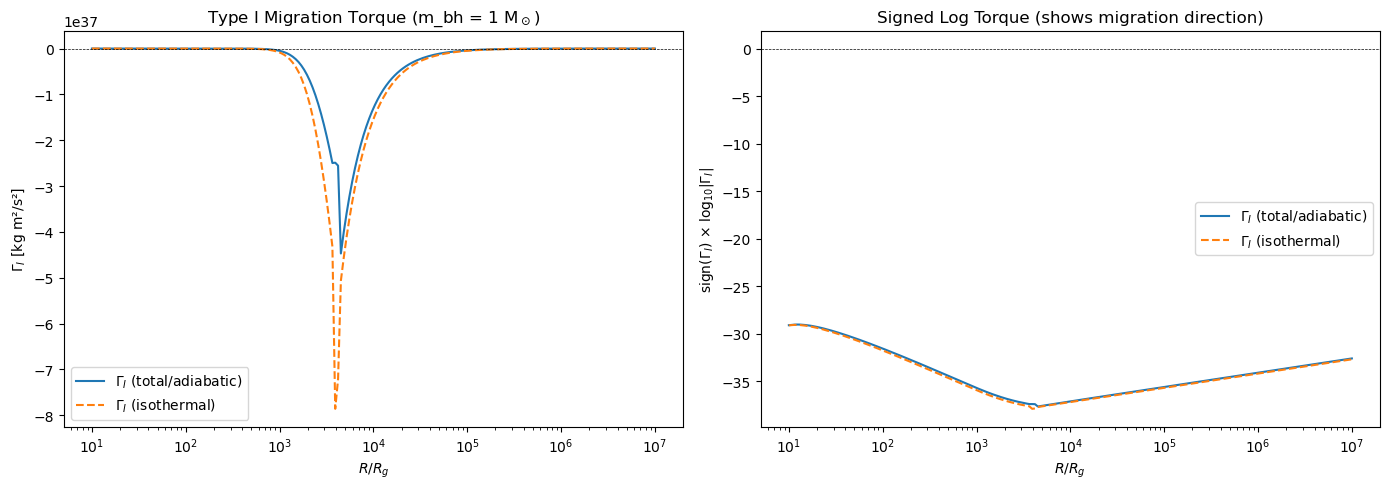

Torque range (total): -4.47e+37 m2 kg / s2 to -1.07e+29 m2 kg / s2
Torque range (iso):   -7.86e+37 m2 kg / s2 to -1.18e+29 m2 kg / s2

Negative torque → inward migration
Positive torque → outward migration (migration trap)


In [12]:
# Main torque plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Torques (log scale for magnitude)
ax = axes[0]
ax.plot(R_Rg, Gamma_I_tot.value, label=r'$\Gamma_I$ (total/adiabatic)')
ax.plot(R_Rg, Gamma_I_iso.value, label=r'$\Gamma_I$ (isothermal)', ls='--')
ax.axhline(0, color='k', ls='--', lw=0.5)
ax.set_xscale('log')
ax.set_xlabel(r'$R/R_g$')
ax.set_ylabel(r'$\Gamma_I$ [kg m²/s²]')
ax.legend()
ax.set_title(f'Type I Migration Torque (m_bh = {mbh.to(u.Msun).value:.0f} M$_\\odot$)')

# Right: Signed log plot to show both positive and negative regions
ax = axes[1]
# Use signed log: sign(x) * log10(|x|)
def signed_log(x):
    return np.sign(x) * np.log10(np.abs(x) + 1e-50)

ax.plot(R_Rg, signed_log(Gamma_I_tot.value), label=r'$\Gamma_I$ (total/adiabatic)')
ax.plot(R_Rg, signed_log(Gamma_I_iso.value), label=r'$\Gamma_I$ (isothermal)', ls='--')
ax.axhline(0, color='k', ls='--', lw=0.5)
ax.set_xscale('log')
ax.set_xlabel(r'$R/R_g$')
ax.set_ylabel(r'sign($\Gamma_I$) $\times$ log$_{10}$|$\Gamma_I$|')
ax.legend()
ax.set_title('Signed Log Torque (shows migration direction)')

plt.tight_layout()
plt.show()

# Print summary
print(f"Torque range (total): {Gamma_I_tot.min():.2e} to {Gamma_I_tot.max():.2e}")
print(f"Torque range (iso):   {Gamma_I_iso.min():.2e} to {Gamma_I_iso.max():.2e}")
print(f"\nNegative torque → inward migration")
print(f"Positive torque → outward migration (migration trap)")

## Interpretation of Type I Migration Torque Results

### Migration Direction
- **Negative torque ($\Gamma_I < 0$)**: Object loses angular momentum → **inward migration** toward SMBH
- **Positive torque ($\Gamma_I > 0$)**: Object gains angular momentum → **outward migration** away from SMBH

### Total vs. Isothermal Torques
The two calculations represent different thermal physics:

1. **Total/Adiabatic torque** (solid line): Full treatment including thermal diffusivity $\chi$
   - Uses $C_I = C_L + (0.46 - 0.96\nabla_\Sigma + 1.8\nabla_T)/\gamma$
   - Accounts for finite thermal relaxation via $f_\gamma(x)$ where $x = \chi/(H^2\Omega)$
   - More physically realistic for regions with finite thermal diffusion

2. **Isothermal torque** (dashed line): Assumes instant thermal relaxation ($x \to 0$)
   - Uses $C_I = -1.36 - 0.54\nabla_\Sigma - 0.5\nabla_T$
   - Appropriate when thermal timescale $\ll$ dynamical timescale
   - Typically valid in optically thin or highly conductive regions

### Migration Traps
Regions where the torque **changes sign** (crosses zero) are **migration traps**:
- Objects migrate inward from large radii until reaching the trap
- Objects migrate outward from small radii until reaching the trap
- **Net result**: Objects accumulate at the migration trap radius, potentially leading to enhanced merger rates or hierarchical growth

Look for zero-crossings in $C_I$ or $\Gamma_I$ plots to identify trap locations in $R/R_g$ space.

### Physical Implications
- Most AGN disks show **predominantly inward migration** (negative torques)
- Presence of migration traps can **halt inward migration** and concentrate stellar-mass objects
- Differences between total and isothermal cases highlight the importance of **thermal physics** in Type I migration
- The signed log plot helps visualize migration direction across many orders of magnitude in torque strength

In [ ]:
# Verification: Check consistency with expectations
print("=" * 60)
print("VERIFICATION OF TYPE I MIGRATION TORQUES")
print("=" * 60)

# 1. Check gradient values (typical SS disk: grad_T ~ 0.5-1, grad_Sigma ~ 0.5-1.5)
print(f"\n1. Gradient ranges:")
print(f"   ∇_T:     {disk.model['grad_T'].min():.2f} to {disk.model['grad_T'].max():.2f}")
print(f"   ∇_Σ:     {disk.model['grad_Sigma'].min():.2f} to {disk.model['grad_Sigma'].max():.2f}")
print(f"   Expected: ∇_T ~ 0.5-1, ∇_Σ ~ 0.5-1.5 for standard SS disk")

# 2. Check C_I values (typically -2 to -4 for inward migration)
print(f"\n2. Torque coefficient C_I ranges:")
print(f"   C_I (total): {CI_tot.min():.2f} to {CI_tot.max():.2f}")
print(f"   C_I (iso):   {CI_iso.min():.2f} to {CI_iso.max():.2f}")
print(f"   Expected: ~ -2 to -4 for typical inward migration")

# 3. Check for migration traps (C_I sign changes)
zero_crossings_tot = np.where(np.diff(np.sign(CI_tot)))[0]
zero_crossings_iso = np.where(np.diff(np.sign(CI_iso)))[0]
print(f"\n3. Migration traps (C_I = 0 crossings):")
print(f"   Total case: {len(zero_crossings_tot)} crossings at R/Rg ≈ {R_Rg[zero_crossings_tot] if len(zero_crossings_tot) > 0 else 'none'}")
print(f"   Iso case:   {len(zero_crossings_iso)} crossings at R/Rg ≈ {R_Rg[zero_crossings_iso] if len(zero_crossings_iso) > 0 else 'none'}")

# 4. Check thermal parameter x (x >> 1 adiabatic, x << 1 isothermal)
print(f"\n4. Thermal parameter x = χ/(H²Ω):")
print(f"   Range: {x_therm.min():.2e} to {x_therm.max():.2e}")
print(f"   x >> 1 (adiabatic) in {np.sum(x_therm > 10)/len(x_therm)*100:.1f}% of disk")
print(f"   x << 1 (isothermal) in {np.sum(x_therm < 0.1)/len(x_therm)*100:.1f}% of disk")

# 5. Check pressure regime
print(f"\n5. Pressure regime (γ):")
print(f"   Radiation dominated (γ=4/3): {np.sum(gamma < 1.5)/len(gamma)*100:.1f}% of disk")
print(f"   Gas dominated (γ=5/3):       {np.sum(gamma > 1.5)/len(gamma)*100:.1f}% of disk")

# 6. Identify the Q=1 transition
q_vals = disk.model['Q'].values
q1_idx = np.argmin(np.abs(q_vals - 1))
print(f"\n6. Q=1 transition at R/Rg ≈ {R_Rg[q1_idx]:.0f}")
print(f"   (Self-regulating zone begins here)")

print("\n" + "=" * 60)